# [LAB-09] 선형회귀ㅣ1-단순선형회귀
## #01. 준비작업
### 1. 라이브러리 참조

In [53]:
# 라이브러리 기본 참조
from jussam import load_data
from helpers import *

# 선형회귀를 위한 참조
# -> 선형회귀 구현 방식이 두 가지 이므로 두 종류의 참조를 모두 가져온다.
from statsmodels.api import add_constant, OLS
from statsmodels. formula.api import ols as formula_ols

### 2. 데이터 가져오기

In [54]:
origin = load_data('cars' )
display(origin.head()) # 상위 5건 출력
display(origin.tail()) # 하위 5건 출력

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


,speed,dist
45,24,70
46,24,92
47,24,93
48,24,120
49,25,85


## #02. 탐색적 데이터 분석
### 1. 종속변수와 독립변수간의 상관분석

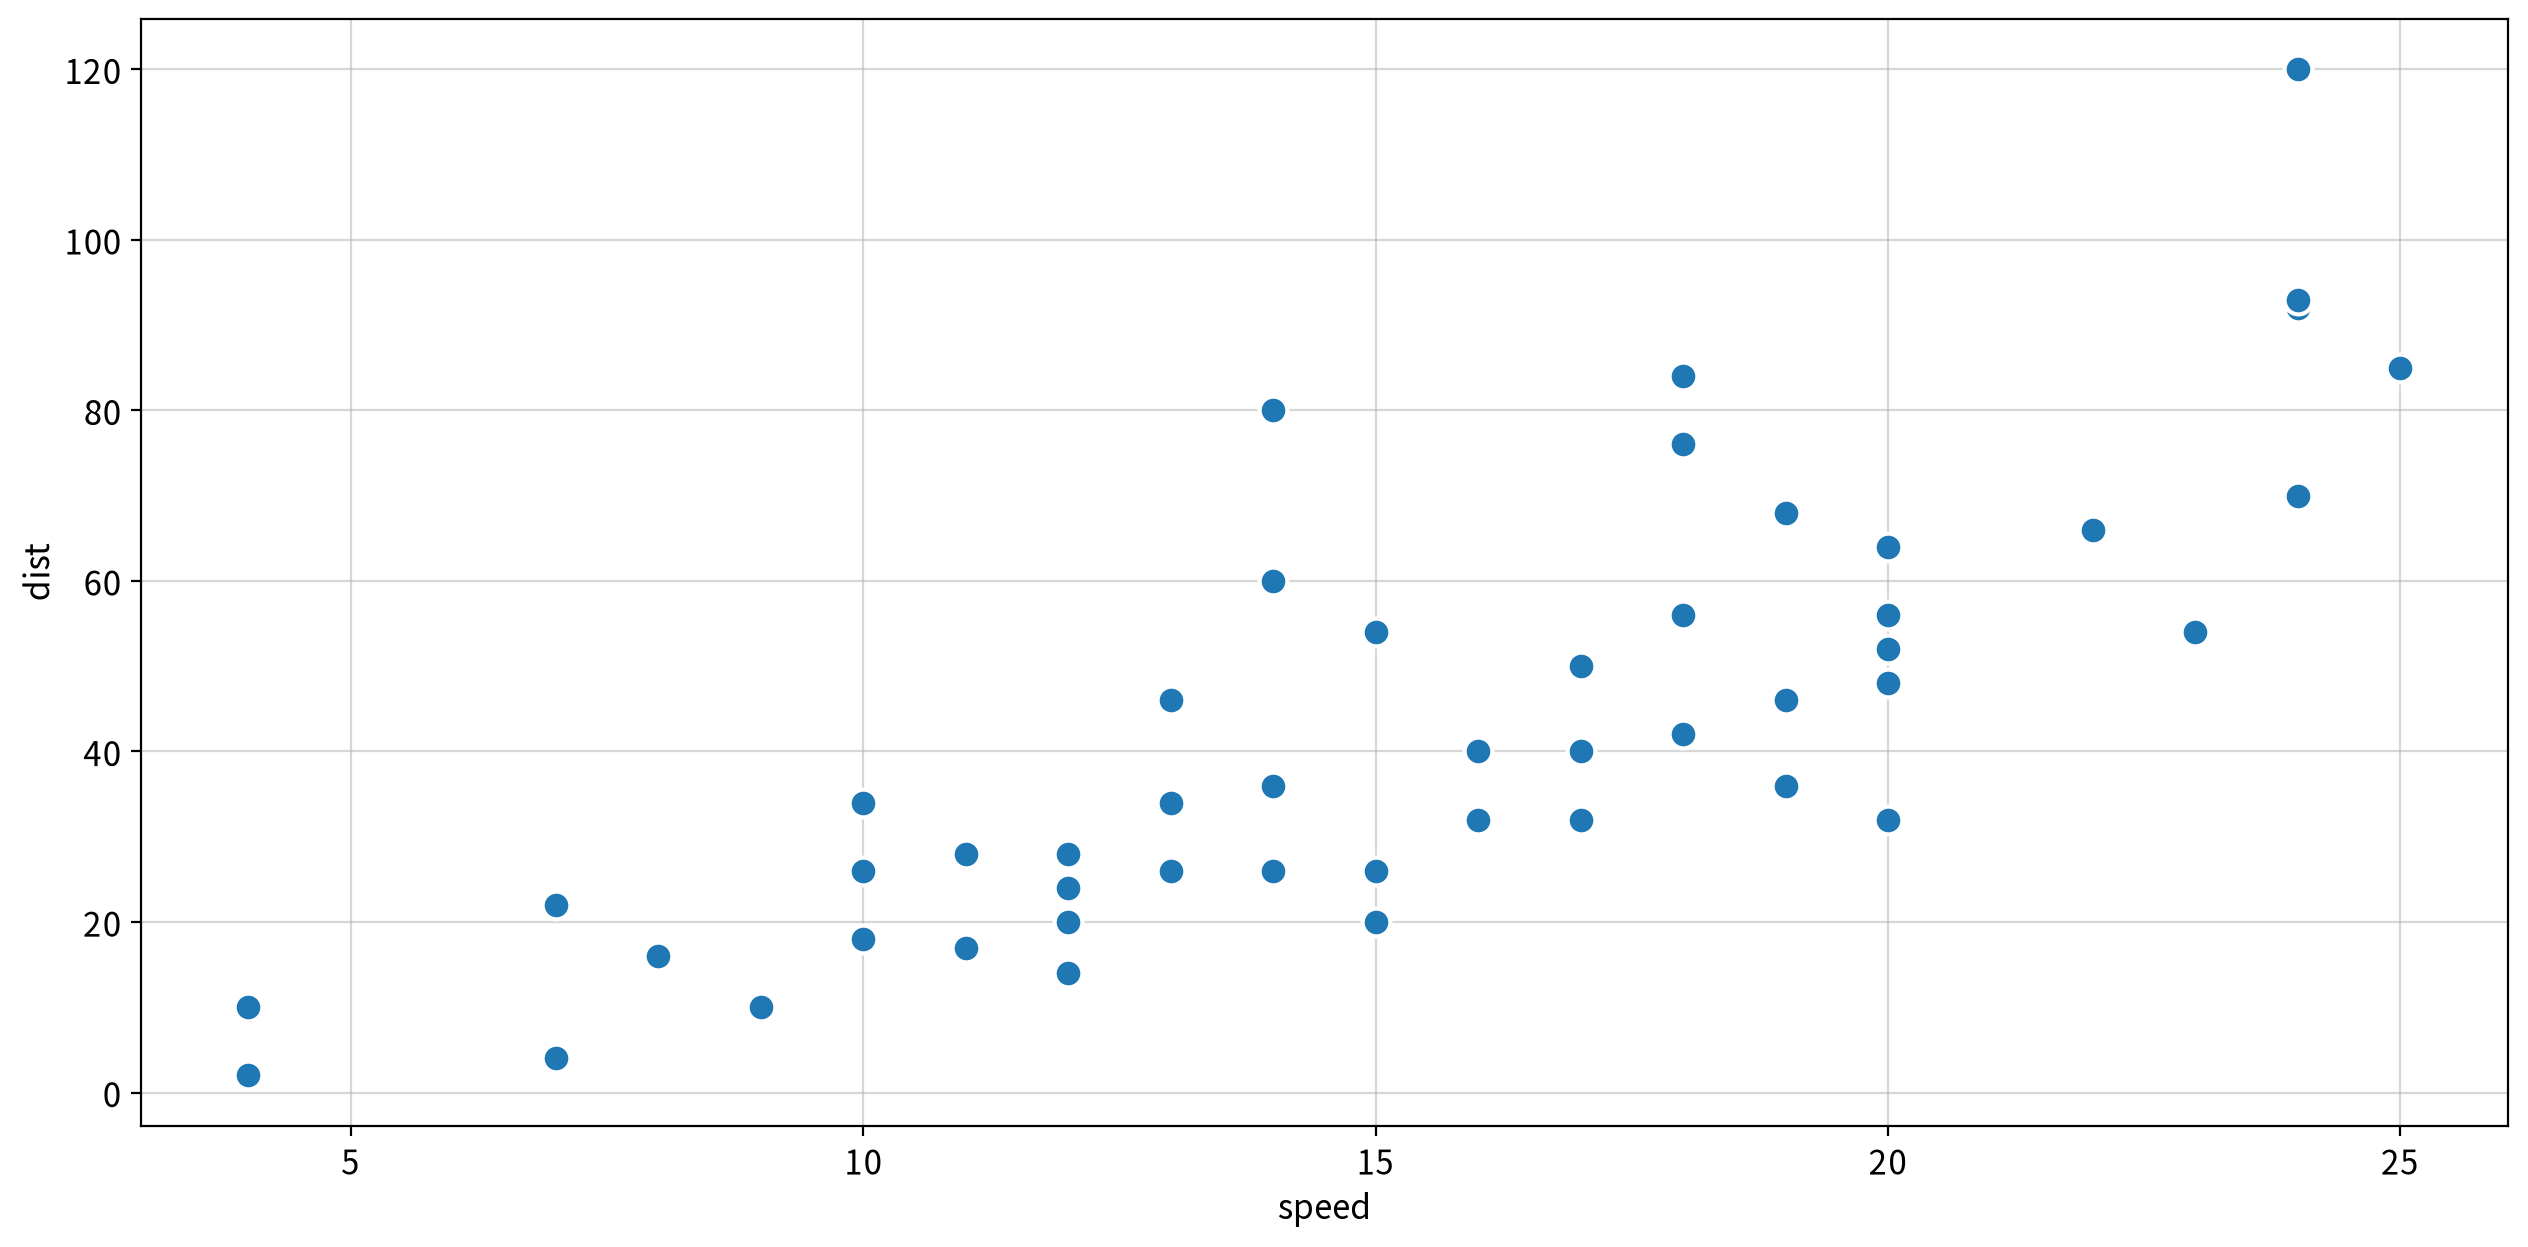

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
speed,dist,Pearson,0.807,0.000,Strong,True,True,True,True,False,False


In [55]:
my_stats.correlation(origin, 'speed', 'dist', plot=True)

## #03. 행렬기반 방식의 단순선형회귀
### 1. 독립변수 행렬 준비
- 독립변수는 행렬(=데이터프레임) 형태로 준비한다
- 이중대괄호는 추출 결과가 데이터프레임이 된다

In [56]:
x = origin[['speed']]
x.head()

,speed
0,4
1,4
2,7
3,7
4,8


### 2. 종속변수 준비
- 종속변수는 벡터(=Series) 형태로 준비한다
- 단일 대괄호는 추출 결과가 Series 객체이다

In [57]:
y = origin['dist']
y.head()

0     2
1    10
2     4
3    22
4    16
Name: dist, dtype: int64

### 3. 상수항 추가
- y = ax + b 형태가 기본형이므로 b 역할을 하기 위한 상수항을 추가해야 한다
- 상수항이 없다면 절편이 0으로 고정된 잘못된 모델이 만들어질 수 있다

In [58]:
x_input = add_constant(x)   # const라는 이름의 상수항 추가
x_input.head()              # 상위 5건 확인

,const,speed
0,1.000,4
1,1.000,4
2,1.000,7
3,1.000,7
4,1.000,8


### 4. 회귀분석 수행

In [59]:
# OLS 모델 객체 생성
# -> 이 단계에서는 아직 학습(fit)되지 않은 '모형의 틀'만 만들어짐
model = OLS(y, x_input)

# 모델 적합(Fit)
# -> 데이터를 이용해 회귀계수(β)를 추정하고, 모델을 완성하는 단계
fit = model.fit()

# 적합된 모델 객체의 분석 결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        12:18:54   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

## #04. formula API 방식의 선형회귀
### 1. 단순선형회귀 구현

In [60]:
# 학습 모델 객체 생성
model = formula_ols('dist ~ speed', data=origin)

# 모델적합
fit = model.fit()

# 분석결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        12:18:54   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

## #05. 실제 데이터와 모형의 예측값 비교
### 1. 원본 데이터 + 가상 데이터 (예측용)

In [61]:
df = origin.copy()

# 최고 속도 이후의 5단계 값을 가상으로 추가한다
for i in range(1,6):
    # df의 인덱스는 0부터 len(df)-1까지 존재하므로,
    # len(df) 위치에 대한 대입은 새로운 행을 추가하는 것과 동일하다
    # -> speed 컬럼에는 최고 속도 + i 값을 대입하고, dist 컬럼에는 None을 대입한다
    df.loc[len(df)] = [df['speed'].max() + i , None]

# 하위 10건 확인
# 마지막에 추가된 5건은 제동거리(dist) 값이 None으로 되어있다
display(df.tail(10))

,speed,dist
45,24.000,70.000
46,24.000,92.000
47,24.000,93.000
48,24.000,120.000
49,25.000,85.000
50,26.000,NaN
51,28.000,NaN
52,31.000,NaN
53,35.000,NaN
54,40.000,NaN


### 2. 예측값 생성
- 분석 모형에 x에 해당하는 speed를 넣어 y에 해당하는 dist가 계산된 값

In [62]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다
predict_input = add_constant(df[['speed']])

# 예측값을 생성하여 pred 컬럼으로 추가한다
df['pred'] = fit.predict(predict_input)

display(df.tail(10)) # 하위 10건 확인

,speed,dist,pred
45,24.000,70.000,76.799
46,24.000,92.000,76.799
47,24.000,93.000,76.799
48,24.000,120.000,76.799
49,25.000,85.000,80.731
50,26.000,NaN,84.664
51,28.000,NaN,92.528
52,31.000,NaN,104.326
53,35.000,NaN,120.055
54,40.000,NaN,139.717


### 3. 시각화를 위해 long타입으로 재배치

In [63]:
df_melt = df.melt(
    id_vars='speed',
    value_vars=['dist', 'pred'],
    var_name='variable',
    value_name='value'
)

display(df_melt.head(10))
display(df_melt.tail(10))

,speed,variable,value
0,4.000,dist,2.000
1,4.000,dist,10.000
2,7.000,dist,4.000
3,7.000,dist,22.000
4,8.000,dist,16.000
5,9.000,dist,10.000
6,10.000,dist,18.000
7,10.000,dist,26.000
8,10.000,dist,34.000
9,11.000,dist,17.000


,speed,variable,value
100,24.000,pred,76.799
101,24.000,pred,76.799
102,24.000,pred,76.799
103,24.000,pred,76.799
104,25.000,pred,80.731
105,26.000,pred,84.664
106,28.000,pred,92.528
107,31.000,pred,104.326
108,35.000,pred,120.055
109,40.000,pred,139.717


### 4. 시각화 비교

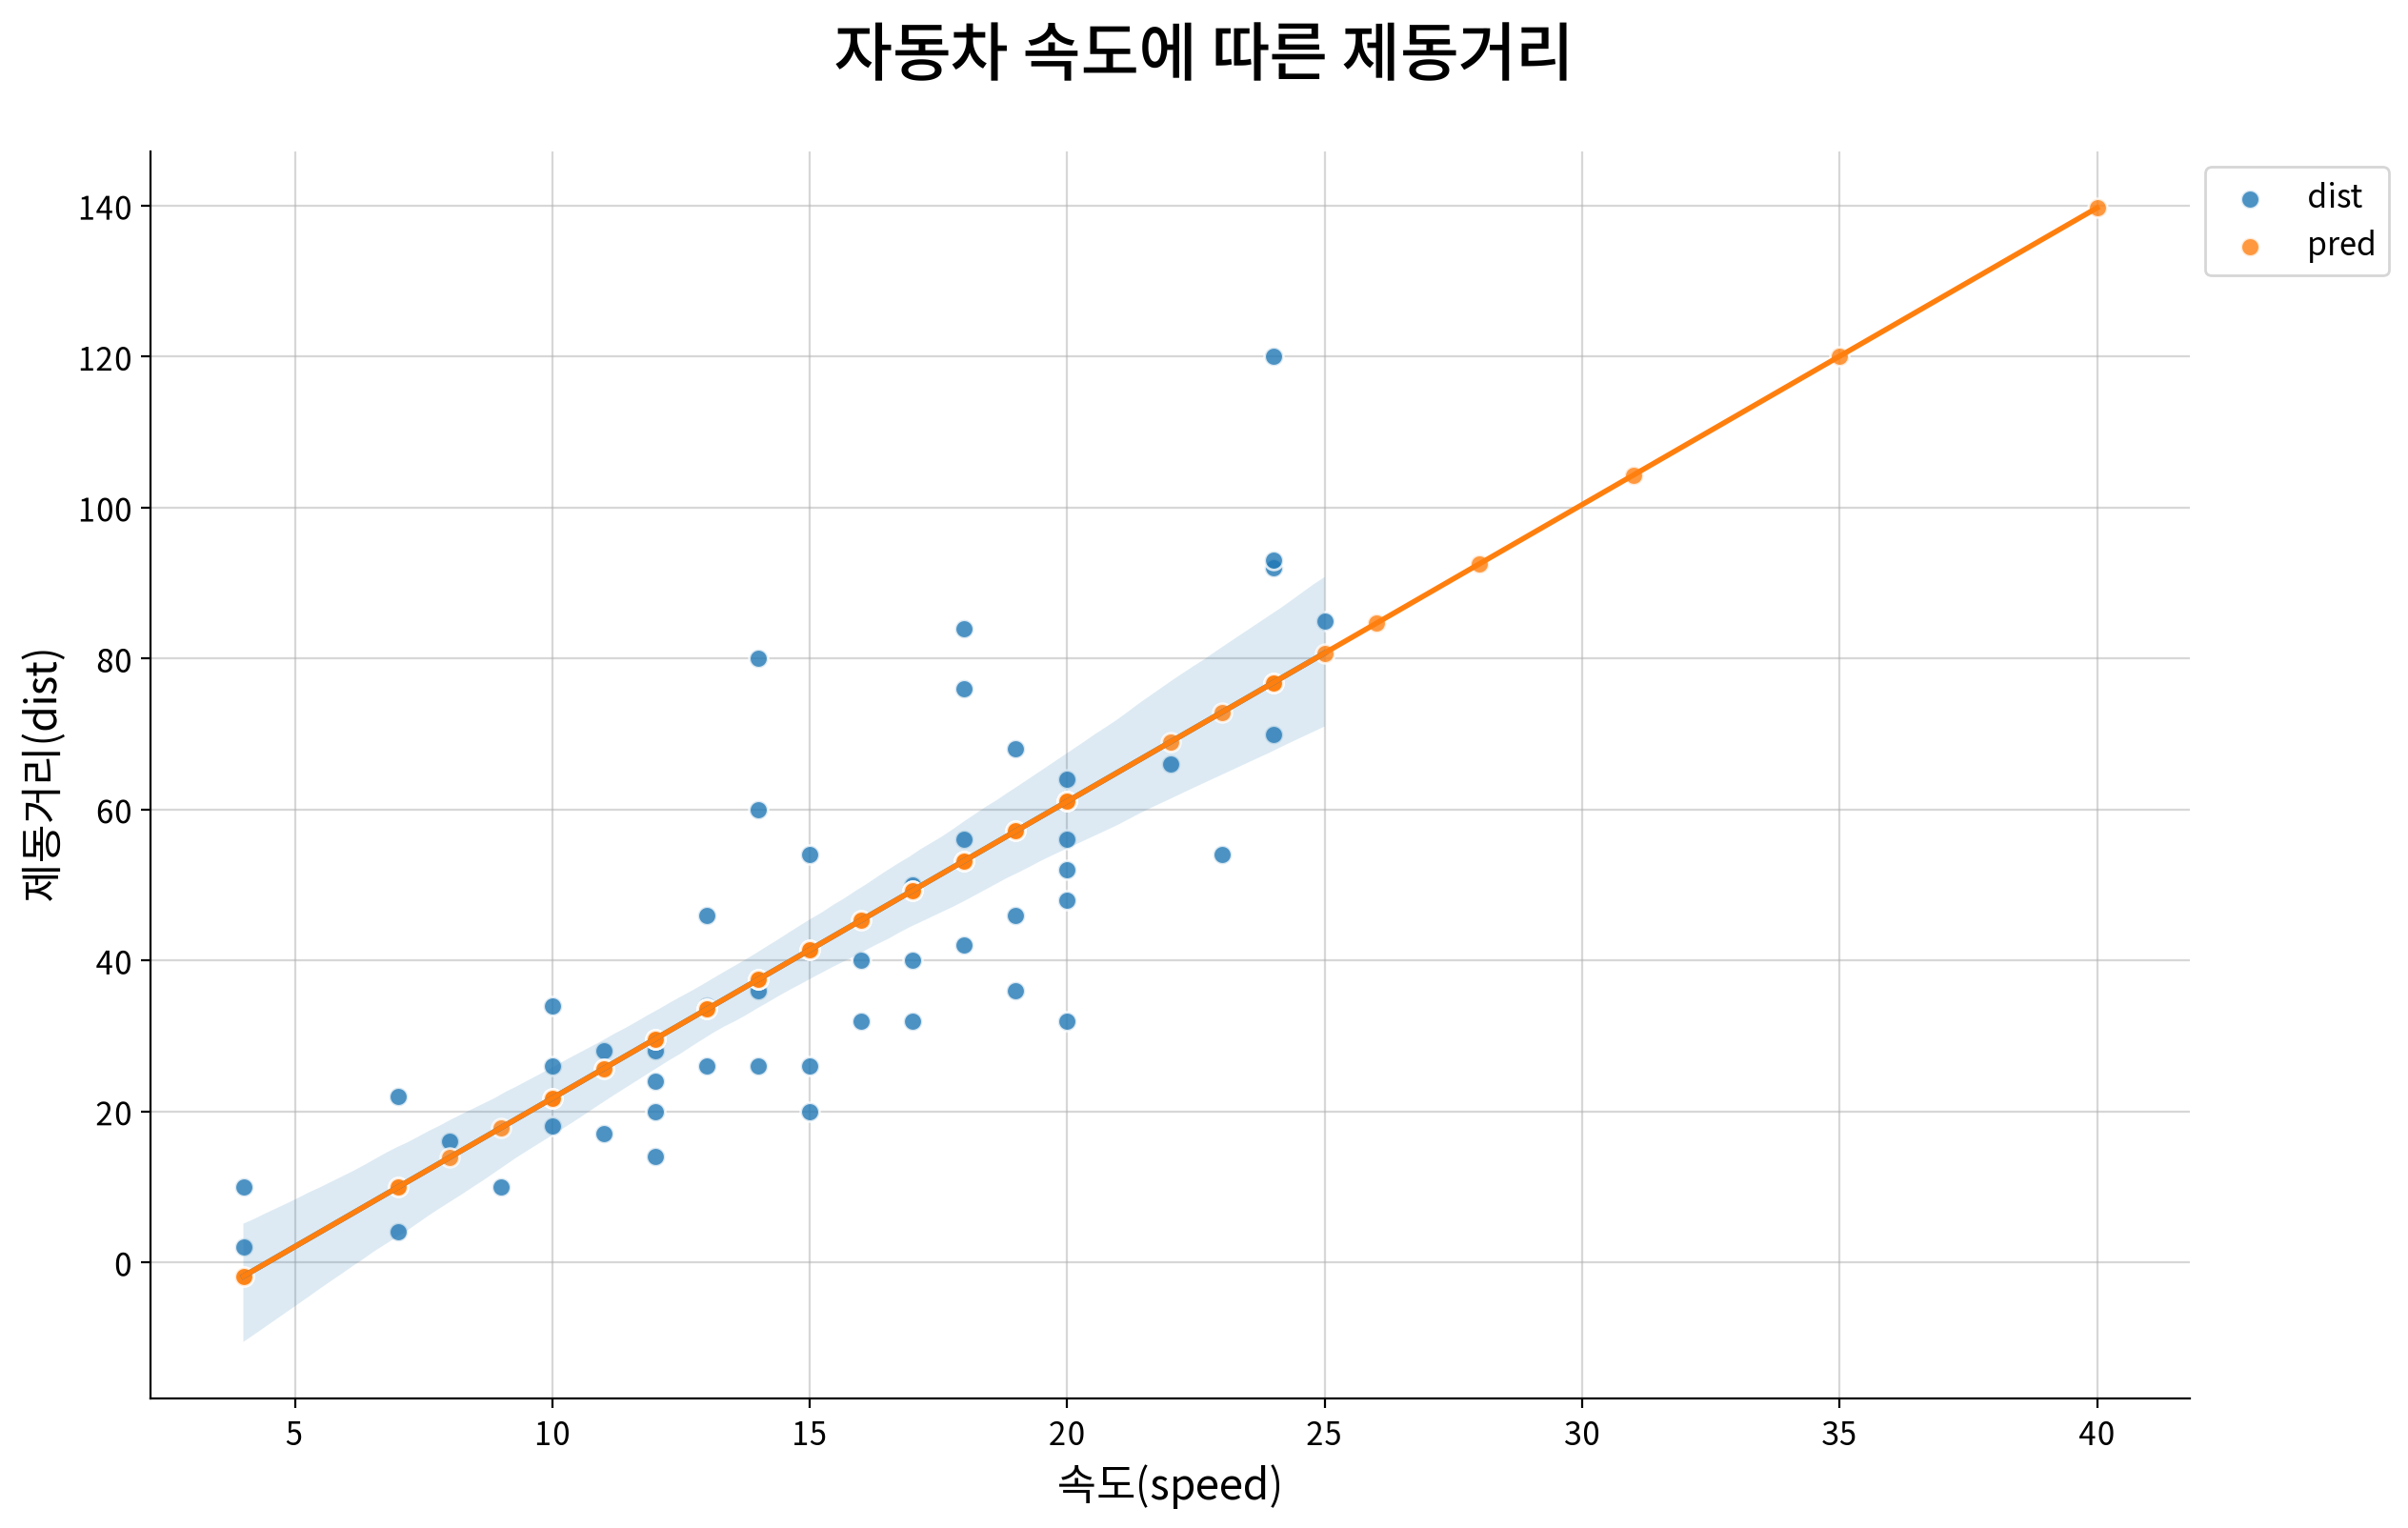

In [64]:
my_plot.lmplot(df_melt, x='speed', y='value', hue='variable',
               title='자동차 속도에 따른 제동거리',
               xlabel='속도(speed)', ylabel='제동거리(dist)')

## #05. 모듈화 기능 확인
### 1. 모델 적합

In [65]:
fit = my_ols.fit_model(origin, y='dist', summary=True)

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        12:18:54   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

### 2. 예측값 생성

In [66]:
pred = my_ols.predict(fit, origin[['speed']])

new_df = origin.copy()
new_df['pred'] = pred
new_df.head()

,speed,dist,pred
0,4,2,-1.849
1,4,10,-1.849
2,7,4,9.948
3,7,22,9.948
4,8,16,13.880


## 연습문제

In [67]:
origin = load_data('father-son')
origin

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281
...,...,...
1073,66.997,70.752
1074,71.332,68.268
1075,71.783,69.306
1076,70.738,69.302


In [68]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   fheight  1078 non-null   float64
 1   sheight  1078 non-null   float64
dtypes: float64(2)
memory usage: 17.0 KB


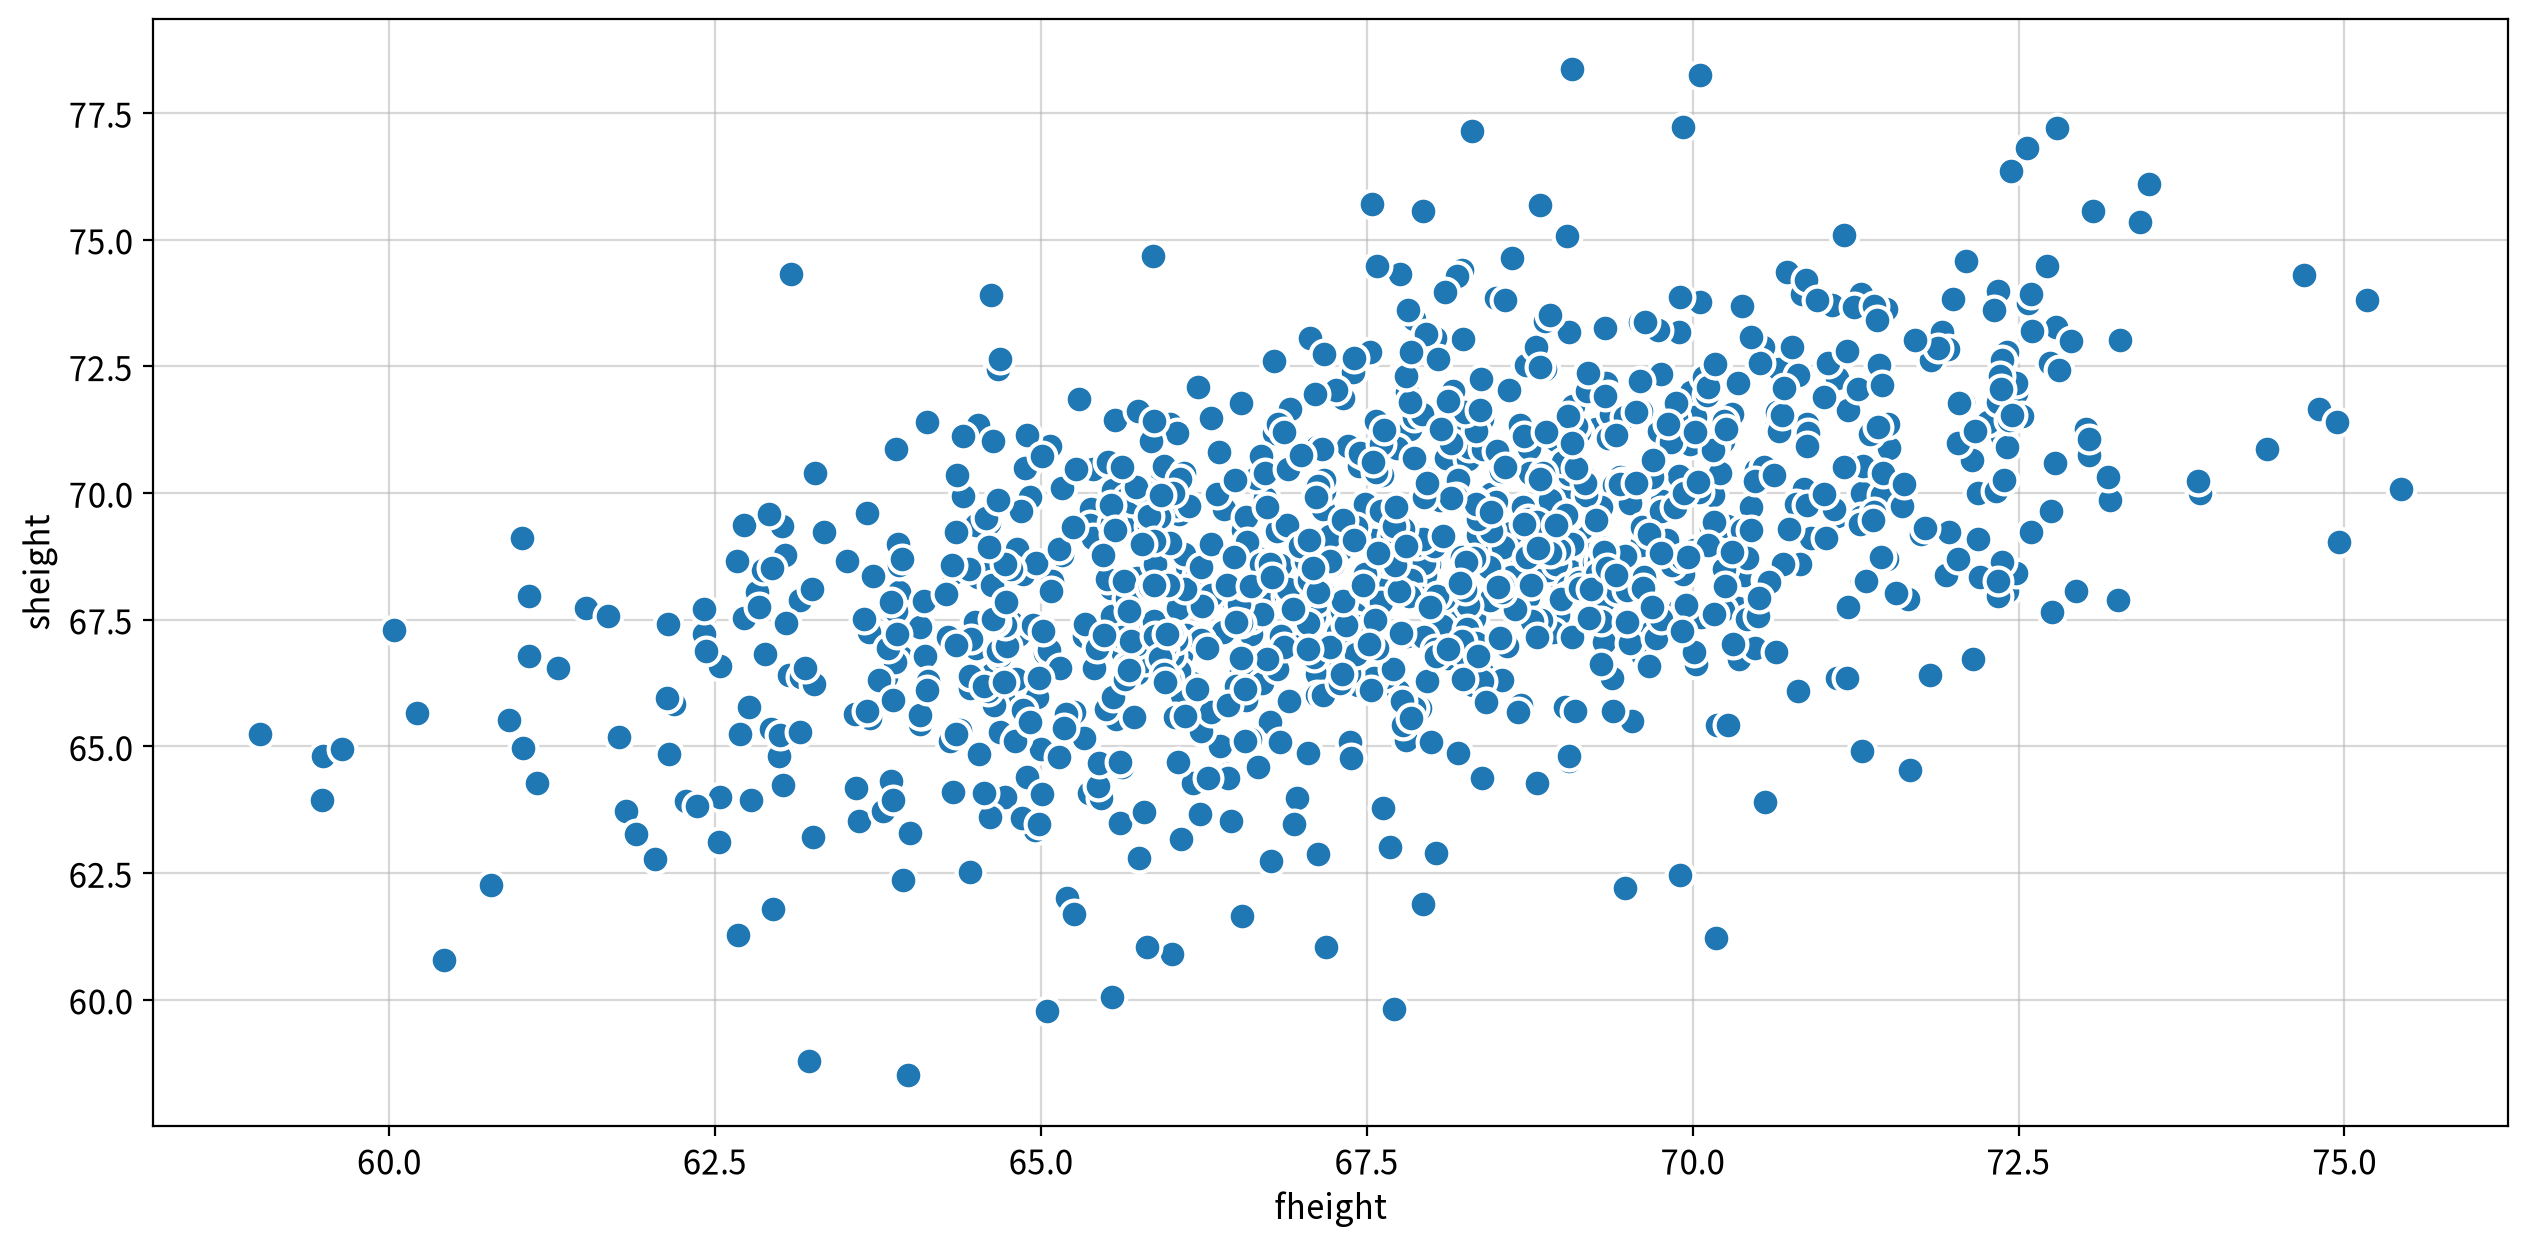

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
fheight,sheight,Spearman,0.506,0.000,Moderate,True,True,False,True,False,False


In [69]:
my_stats.correlation(origin, 'fheight', 'sheight', plot=True)

In [70]:
fit = my_ols.fit_model(origin, y='sheight', summary=True)

                            OLS Regression Results                            
Dep. Variable:                sheight   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     361.2
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.12e-69
Time:                        12:18:54   Log-Likelihood:                -2488.7
No. Observations:                1078   AIC:                             4981.
Df Residuals:                    1076   BIC:                             4991.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8866      1.832     18.493      0.0

> sheight = 0.514 x fheight + 33.886

In [82]:
from pandas import DataFrame, concat
df = origin.copy()

# 새로운 키 / 그에 따른 예측 키 컬럼 만들기
new_x = DataFrame({'fheight':[73.5, 72.6, 68.3, 71.9, 74.1]})
pred = my_ols.predict(fit, new_x)

# 새로운 키와 예측값만 모아놓은 데이터프레임 만들기
new_df = new_x.copy()
new_df['sheight'] = pred['pred']
new_df

,fheight,sheight
0,73.500,71.672
1,72.600,71.210
2,68.300,68.999
3,71.900,70.850
4,74.100,71.981


In [84]:
real_df = df.copy()
real_df['source'] = '실제 데이터'
new_df['source'] = '가상 데이터'

merged = concat([real_df, new_df], ignore_index=True)
print(f'▶ 병합 데이터셋 크기 : {merged.shape[0]}행 (실제 {len(real_df)} + 가상 {len(new_df)})')
print('\n▶ 병합 결과의 마지막 8행 (예측된 가상 5명 포함):')
merged.tail(8)

▶ 병합 데이터셋 크기 : 1083행 (실제 1078 + 가상 5)

▶ 병합 결과의 마지막 8행 (예측된 가상 5명 포함):


,fheight,sheight,source
1075,71.783,69.306,실제 데이터
1076,70.738,69.302,실제 데이터
1077,70.306,67.015,실제 데이터
1078,73.500,71.672,가상 데이터
1079,72.600,71.210,가상 데이터
1080,68.300,68.999,가상 데이터
1081,71.900,70.850,가상 데이터
1082,74.100,71.981,가상 데이터


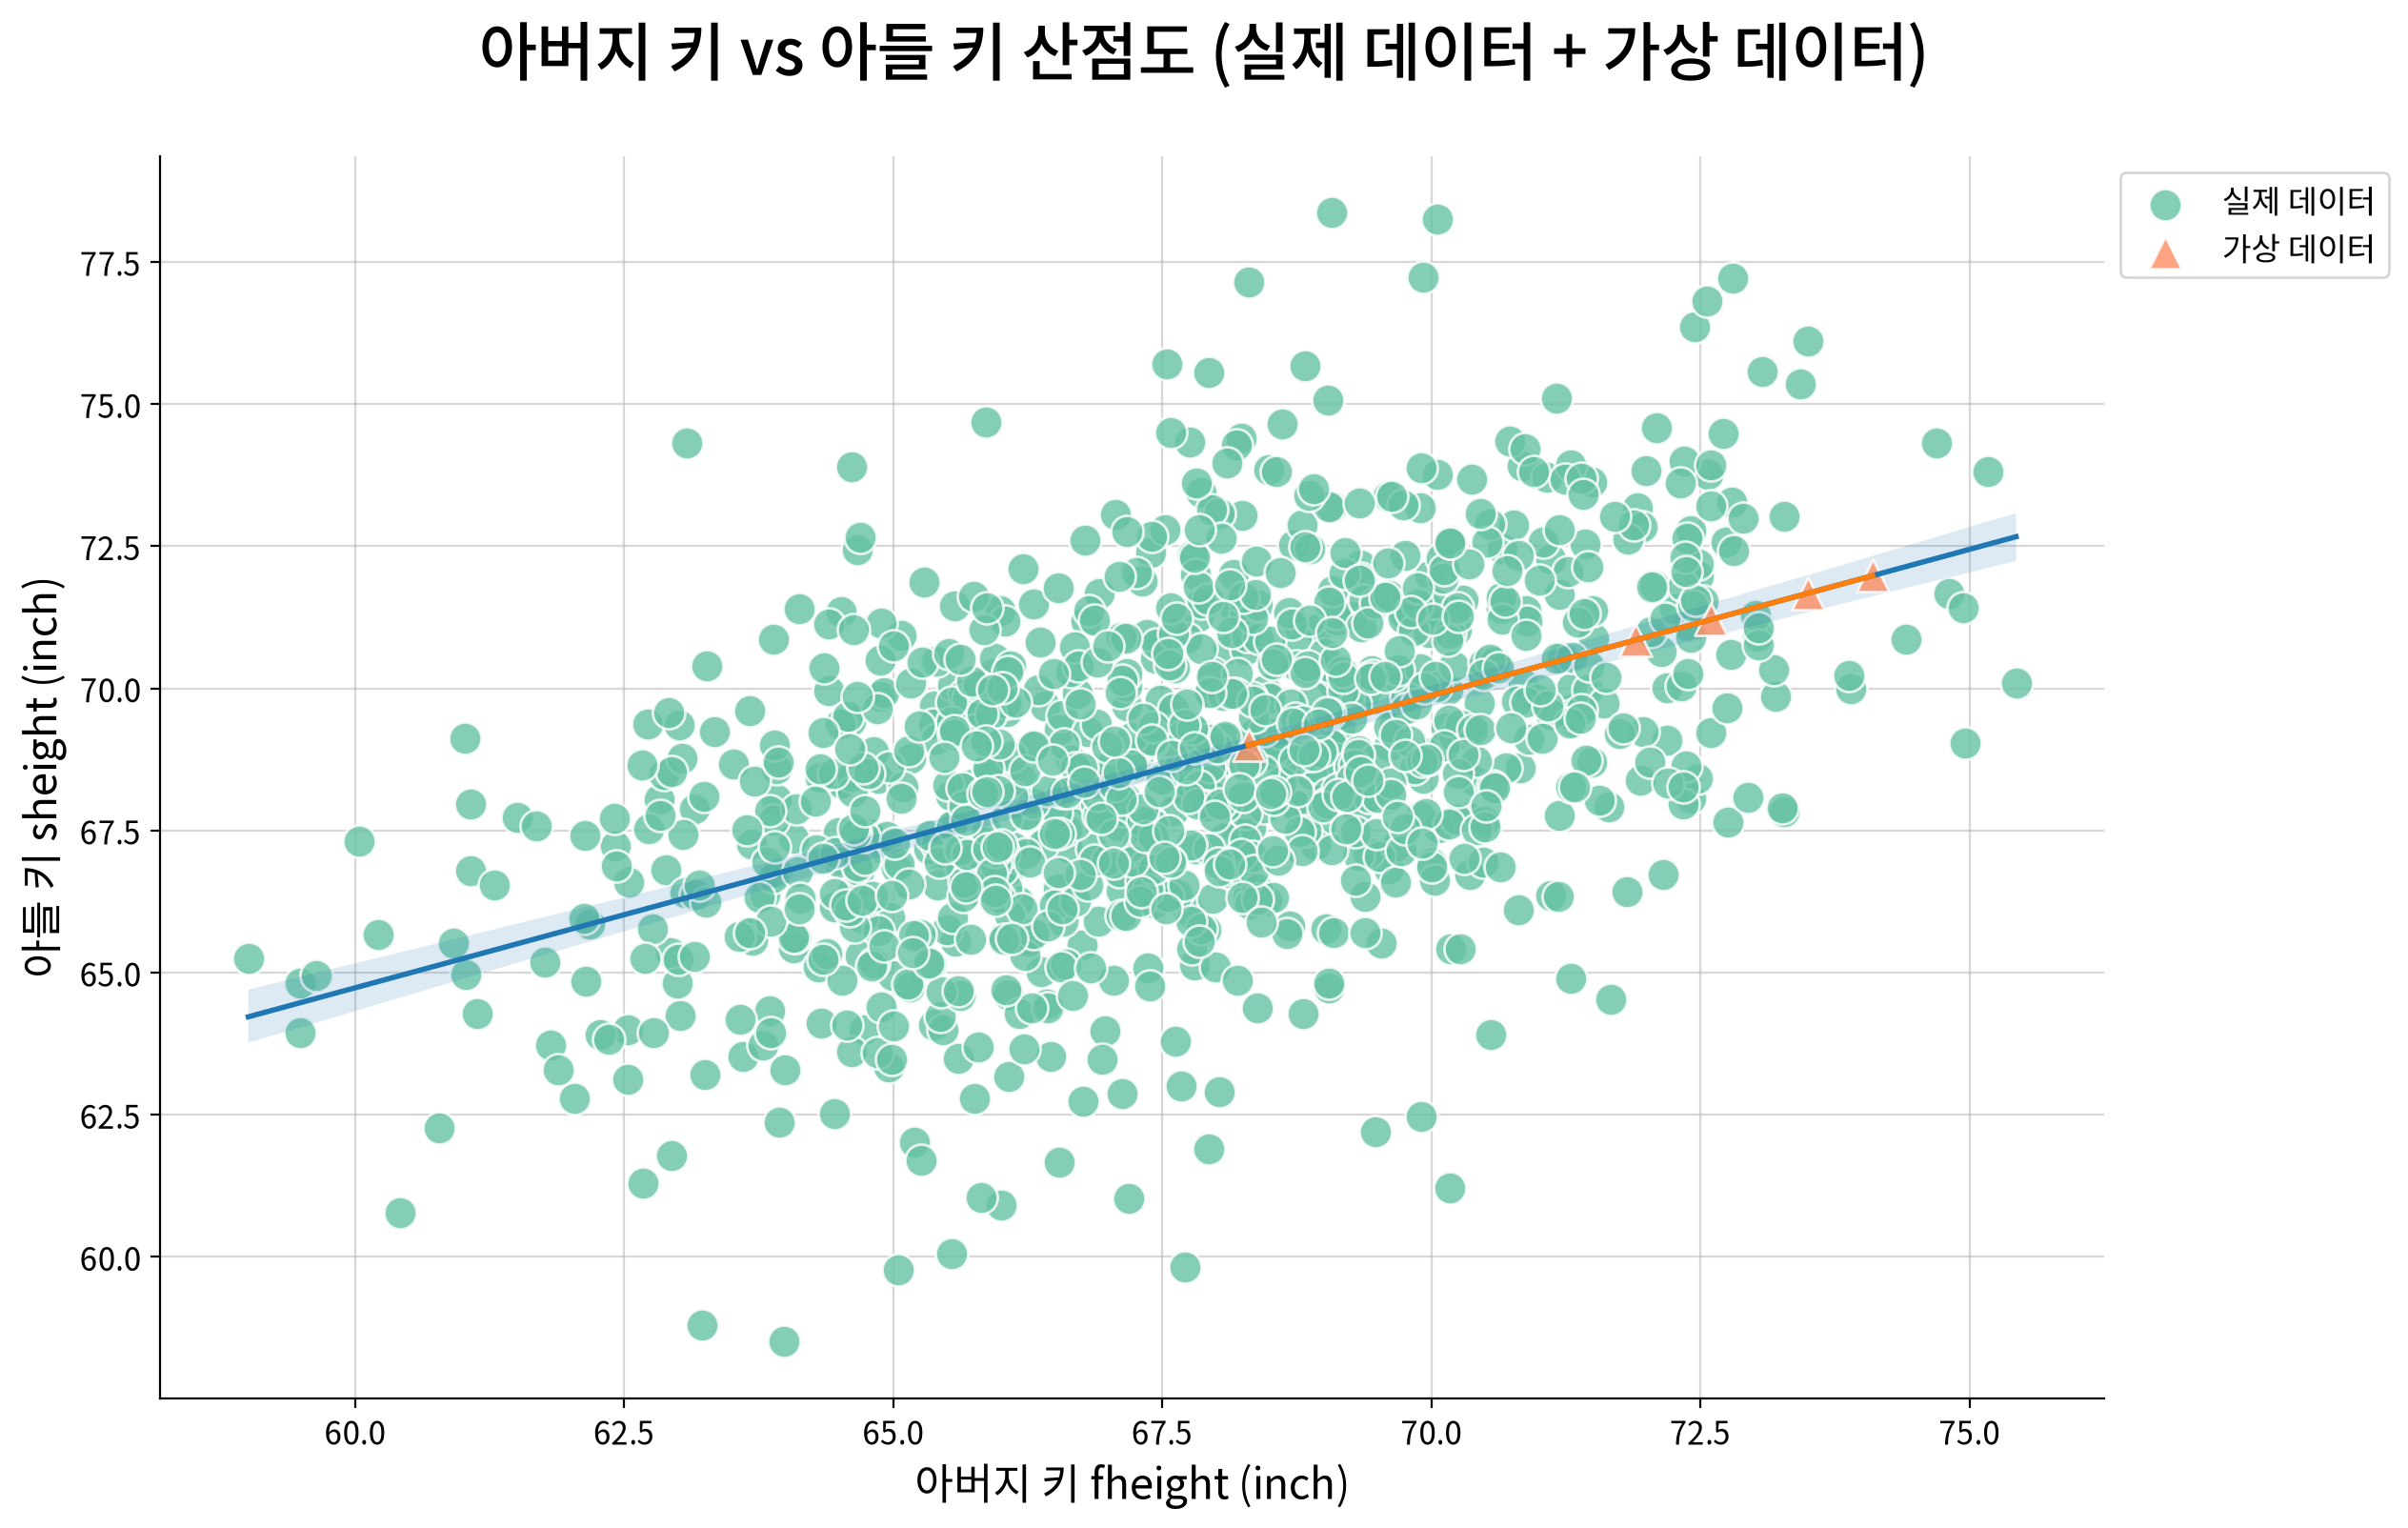

In [85]:
my_plot.lmplot(
    merged, x='fheight', y='sheight', hue='source',
    markers=['o', '^'], palette='Set2', scatter_size=150,
    title='아버지 키 vs 아들 키 산점도 (실제 데이터 + 가상 데이터)',
    xlabel='아버지 키 fheight (inch)', ylabel='아들 키 sheight (inch)')

In [ ]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다
predict_input = add_constant(df[['fheight']])

# 예측값을 생성하여 pred 컬럼으로 추가한다
df['pred'] = fit.predict(predict_input)

display(df.tail(10)) # 하위 10건 확인

,fheight,sheight,pred
1073,66.997,70.752,68.329
1074,71.332,68.268,70.558
1075,71.783,69.306,70.790
1076,70.738,69.302,70.253
1077,70.306,67.015,70.030
1078,73.500,NaN,71.672
1079,72.600,NaN,71.210
1080,68.300,NaN,68.999
1081,71.900,NaN,70.850
1082,74.100,NaN,71.981


In [ ]:
df_melt = df.melt(
    id_vars='fheight',
    value_vars=['sheight', 'pred'],
    var_name='variable',
    value_name='value'
)

display(df_melt.head(10))
display(df_melt.tail(10))

,fheight,variable,value
0,65.049,sheight,59.778
1,63.251,sheight,63.214
2,64.955,sheight,63.342
3,65.752,sheight,62.792
4,61.137,sheight,64.281
5,63.023,sheight,64.242
6,65.371,sheight,64.082
7,64.724,sheight,63.996
8,66.065,sheight,64.613
9,66.967,sheight,63.979


,fheight,variable,value
2156,66.997,pred,68.329
2157,71.332,pred,70.558
2158,71.783,pred,70.790
2159,70.738,pred,70.253
2160,70.306,pred,70.030
2161,73.500,pred,71.672
2162,72.600,pred,71.210
2163,68.300,pred,68.999
2164,71.900,pred,70.850
2165,74.100,pred,71.981


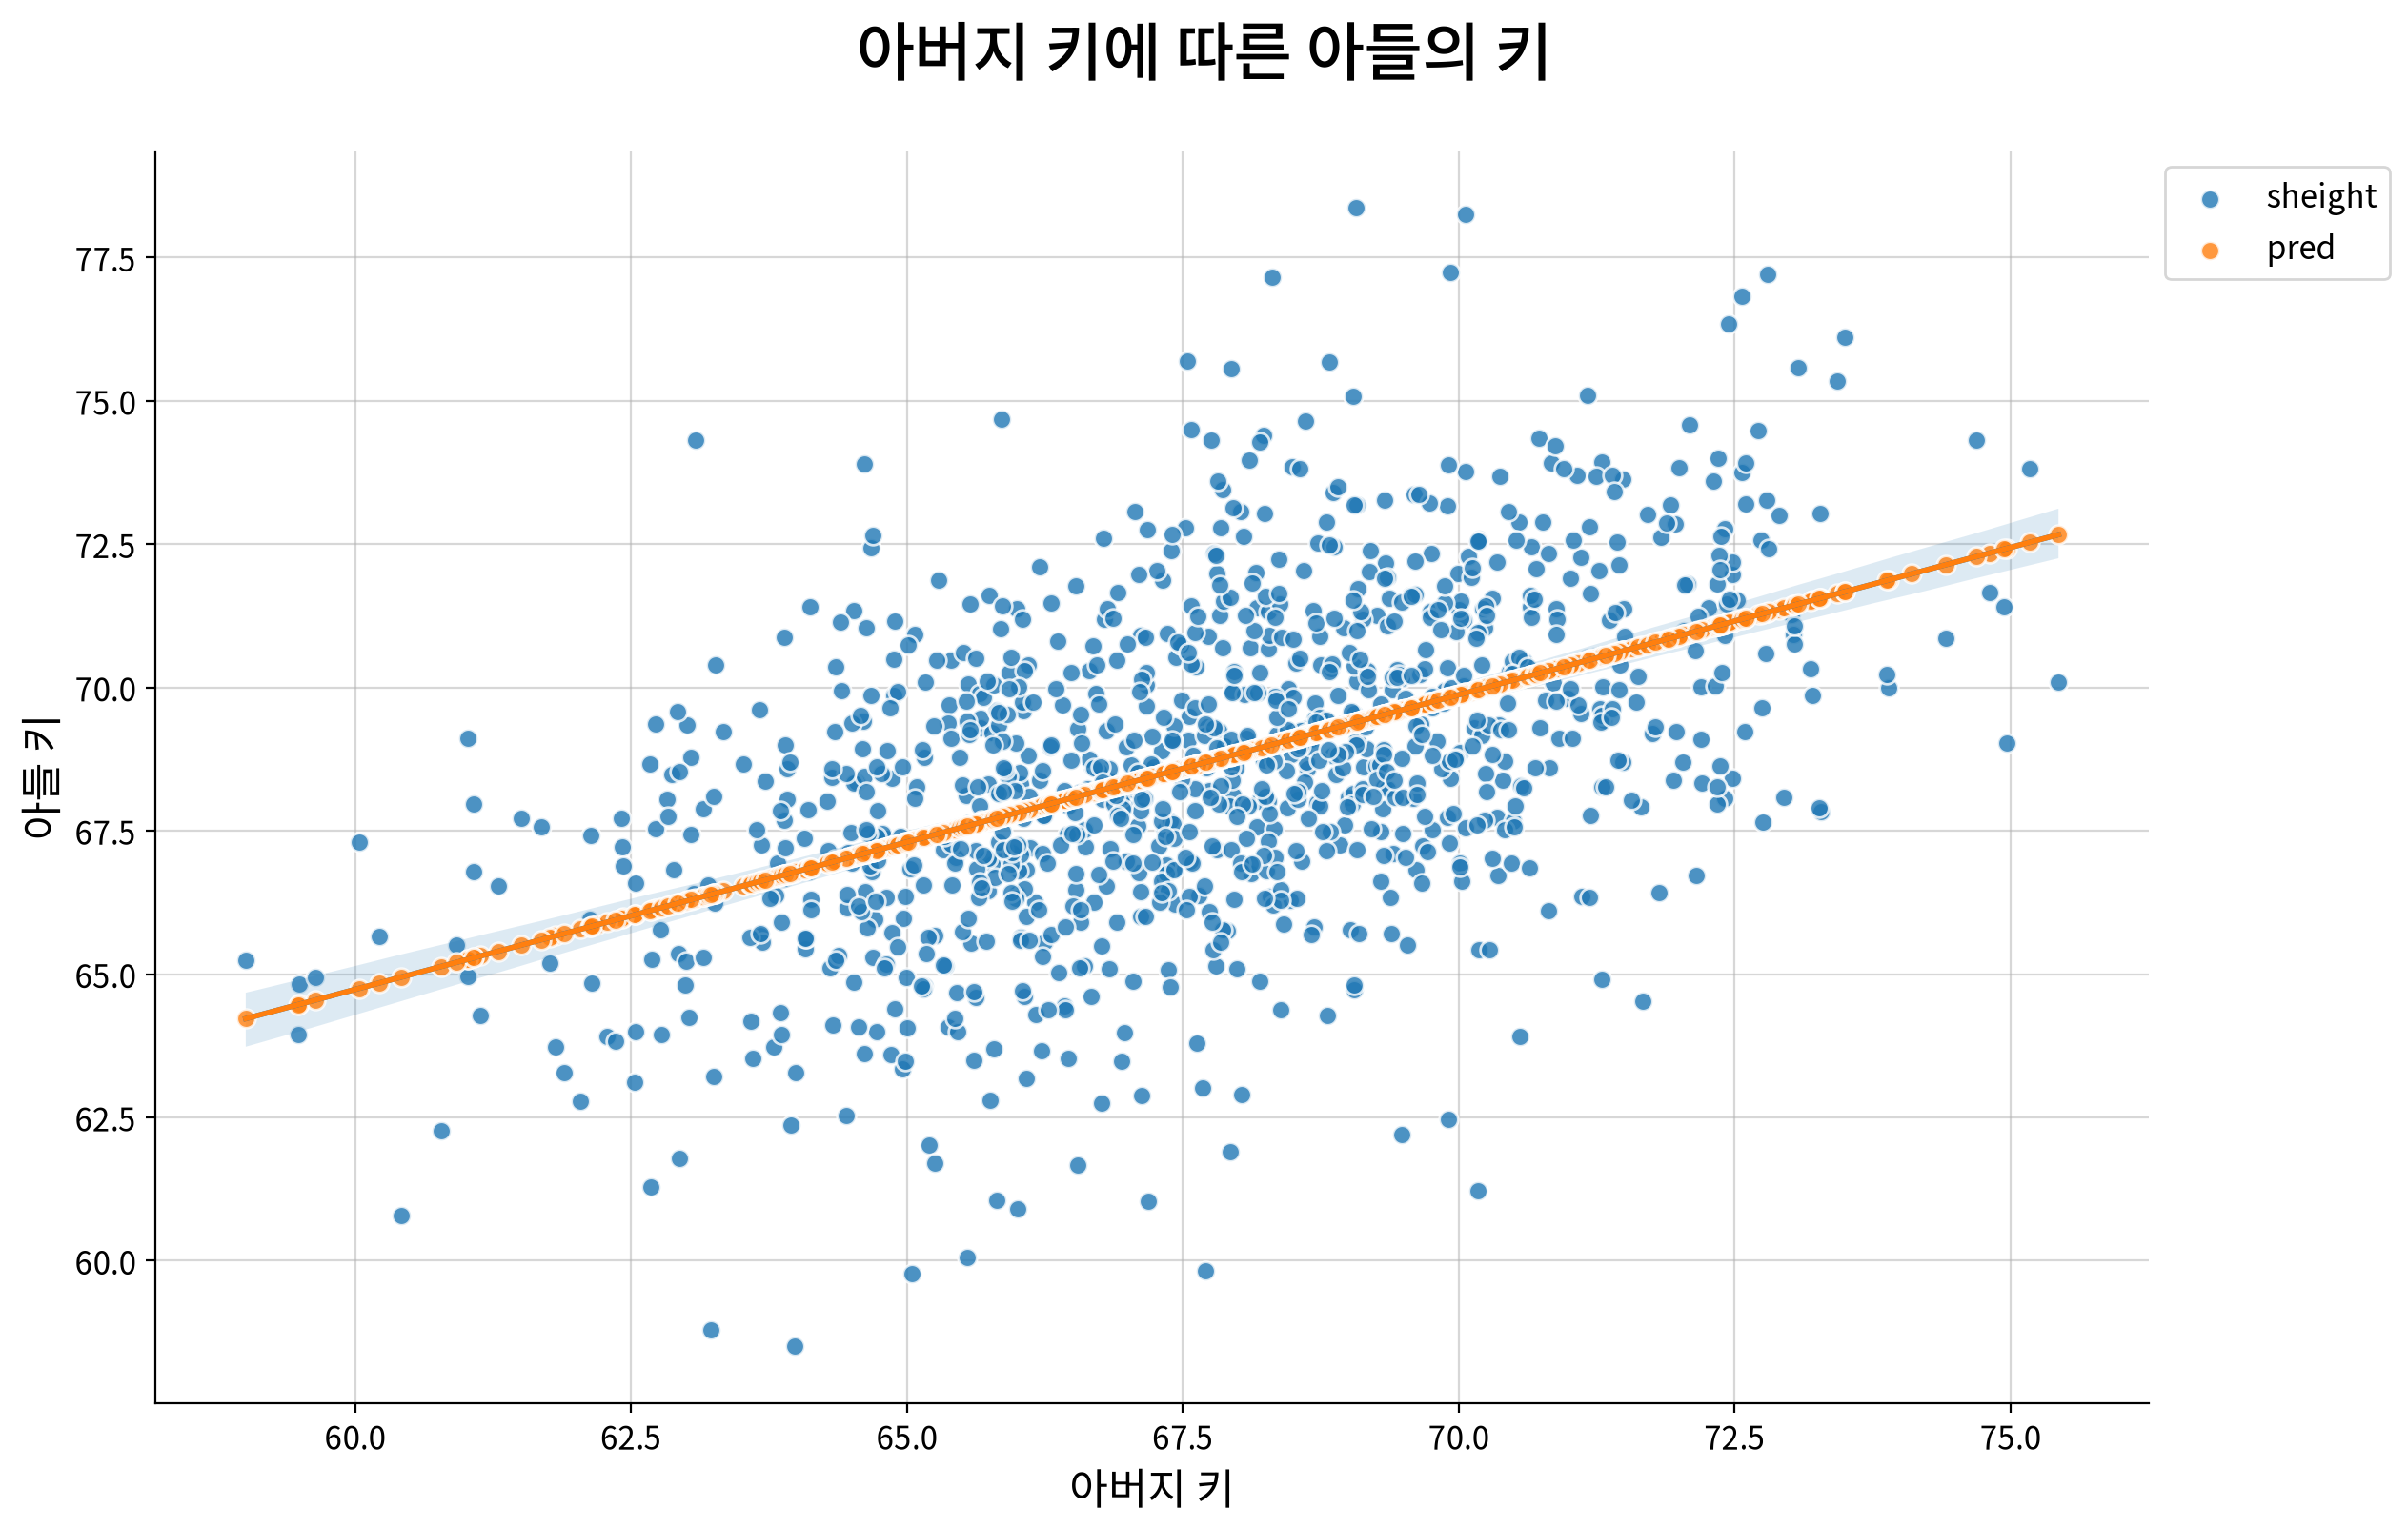

In [ ]:
my_plot.lmplot(df_melt, x='fheight', y='value', hue='variable',
               title='아버지 키에 따른 아들의 키',
               xlabel='아버지 키', ylabel='아들 키')